<a href="https://colab.research.google.com/github/Chathuwa99/Agri_Bloom/blob/Yehan/Agri_Bloom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Agri_Bloom

**Module:** CM3603 — Edge Artificial Intelligence  
**Project:** Agri_Bloom — Smart Tomato Seedling Monitor  
**Runtime:** Google Colab · T4 GPU  
**Dataset:** `agribloom_dataset.csv` — 3,800 samples · 4 features · 7 classes



---
## Mount Google Drive & Load Dataset

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [2]:
import pandas as pd
import numpy as np

DATASET_PATH = '/content/drive/MyDrive/Agri-Bloom/agribloom_dataset.csv'
OUTPUT_DIR   = '/content/drive/MyDrive/Agri-Bloom/outputs/'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the CSV
df = pd.read_csv(DATASET_PATH)

print(f'   Dataset loaded successfully.')
print(f'   Rows     : {len(df)}')
print(f'   Columns  : {list(df.columns)}')
print(f'   Shape    : {df.shape}')
df.head()

   Dataset loaded successfully.
   Rows     : 3800
   Columns  : ['moisture_pct', 'lux', 'temperature', 'humidity_pct', 'diagnosis']
   Shape    : (3800, 5)


,moisture_pct,lux,temperature,humidity_pct,diagnosis
0,63.93,1497.57,20.88,90.93,Fungal_Risk
1,59.46,2830.91,20.67,72.78,Nutrient_Deficiency
2,67.02,3782.61,19.81,79.16,Healthy
3,96.00,1086.99,23.60,83.05,Root_Rot_Risk
4,41.60,4412.47,37.89,35.61,Heat_Stress


---
## Exploratory Data Analysis (EDA)

In [3]:
# Basic info & statistics
print('  Dataset Info')
df.info()
print()
print('Null values per column:')
print(df.isnull().sum())

  Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   moisture_pct  3800 non-null   float64
 1   lux           3800 non-null   float64
 2   temperature   3800 non-null   float64
 3   humidity_pct  3800 non-null   float64
 4   diagnosis     3800 non-null   object 
dtypes: float64(4), object(1)
memory usage: 148.6+ KB

Null values per column:
moisture_pct    0
lux             0
temperature     0
humidity_pct    0
diagnosis       0
dtype: int64


In [4]:
# Descriptive statistics for feature columns
feature_cols = ['moisture_pct', 'lux', 'temperature', 'humidity_pct']
df[feature_cols].describe().round(2)

,moisture_pct,lux,temperature,humidity_pct
count,3800.00,3800.00,3800.00,3800.00
mean,57.44,2356.81,23.94,66.34
std,21.18,1548.62,5.63,20.09
min,10.15,102.24,11.39,20.01
25%,44.19,949.06,20.49,55.63
50%,61.52,2007.59,22.45,68.43
75%,68.01,3709.74,24.74,83.76
max,99.93,7634.55,41.84,99.62


/tmp/ipykernel_4023/3831712875.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.index, rotation=30, ha='right')


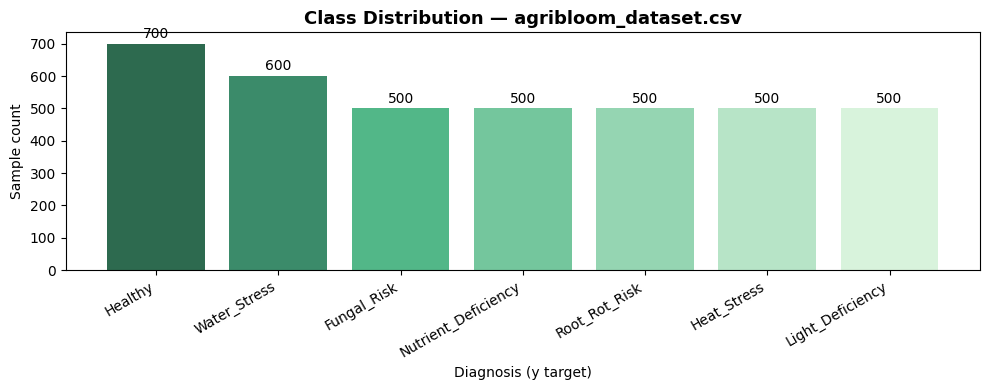

diagnosis
Healthy                700
Water_Stress           600
Fungal_Risk            500
Nutrient_Deficiency    500
Root_Rot_Risk          500
Heat_Stress            500
Light_Deficiency       500
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
class_counts = df['diagnosis'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=['#2D6A4F','#3B8B6A','#52B788','#74C69D','#95D5B2','#B7E4C7','#D8F3DC'])
ax.set_title('Class Distribution — agribloom_dataset.csv', fontsize=13, fontweight='bold')
ax.set_xlabel('Diagnosis (y target)')
ax.set_ylabel('Sample count')
ax.set_xticklabels(class_counts.index, rotation=30, ha='right')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print(class_counts)

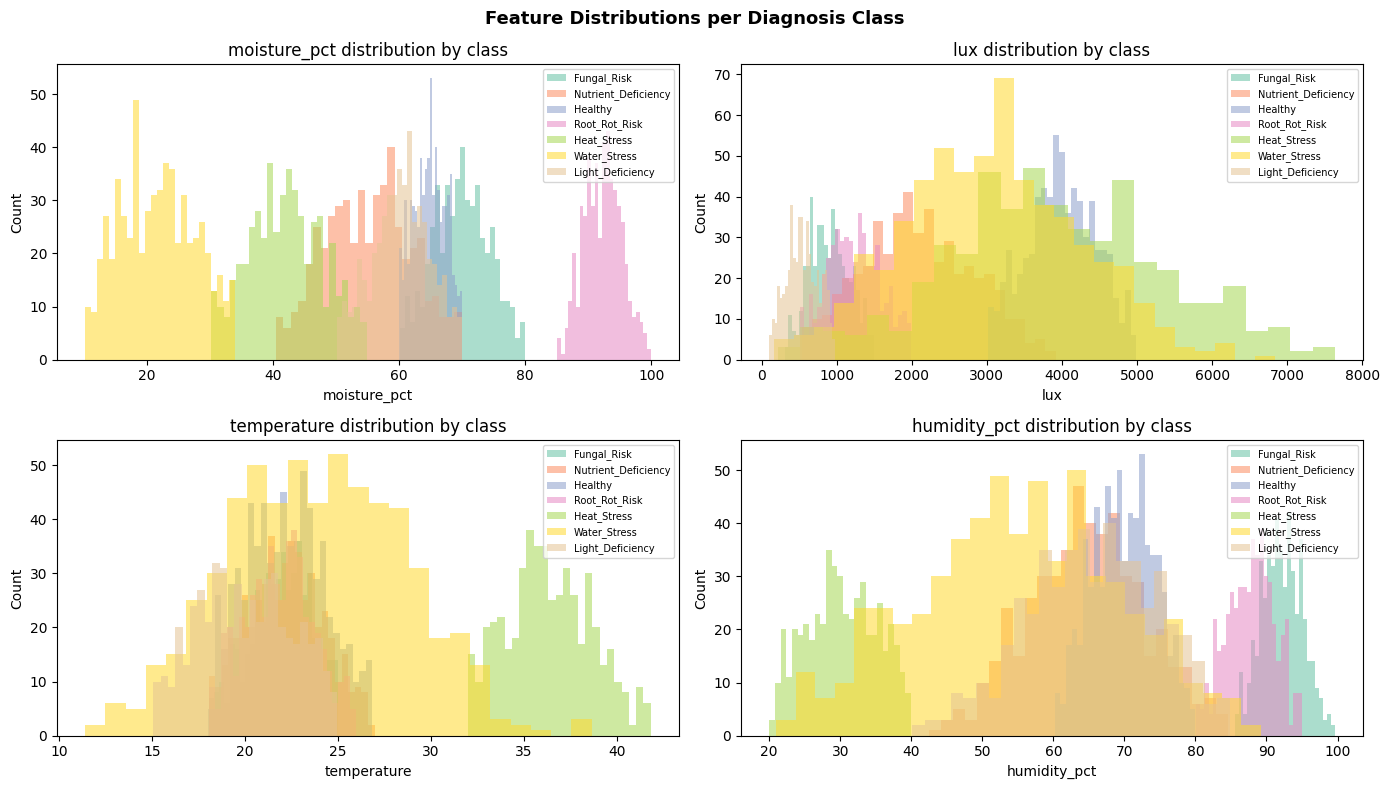

In [6]:
# Feature distributions per class
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = plt.cm.Set2.colors

for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 2][idx % 2]
    for i, cls in enumerate(df['diagnosis'].unique()):
        subset = df[df['diagnosis'] == cls][feature]
        ax.hist(subset, bins=25, alpha=0.55, label=cls, color=colors[i % len(colors)])
    ax.set_title(f'{feature} distribution by class')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Feature Distributions per Diagnosis Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

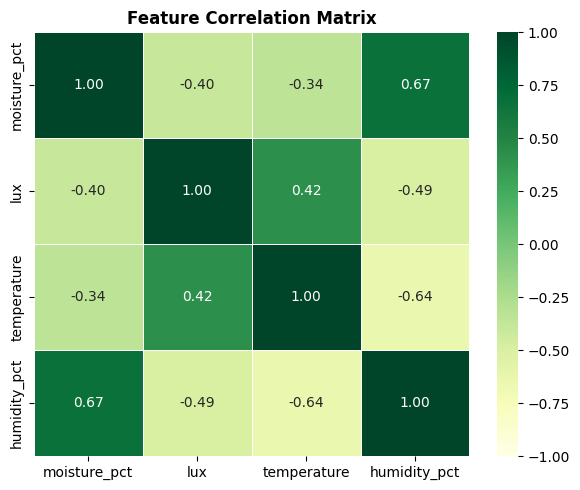

In [7]:
# Correlation heatmap (numeric features only)
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

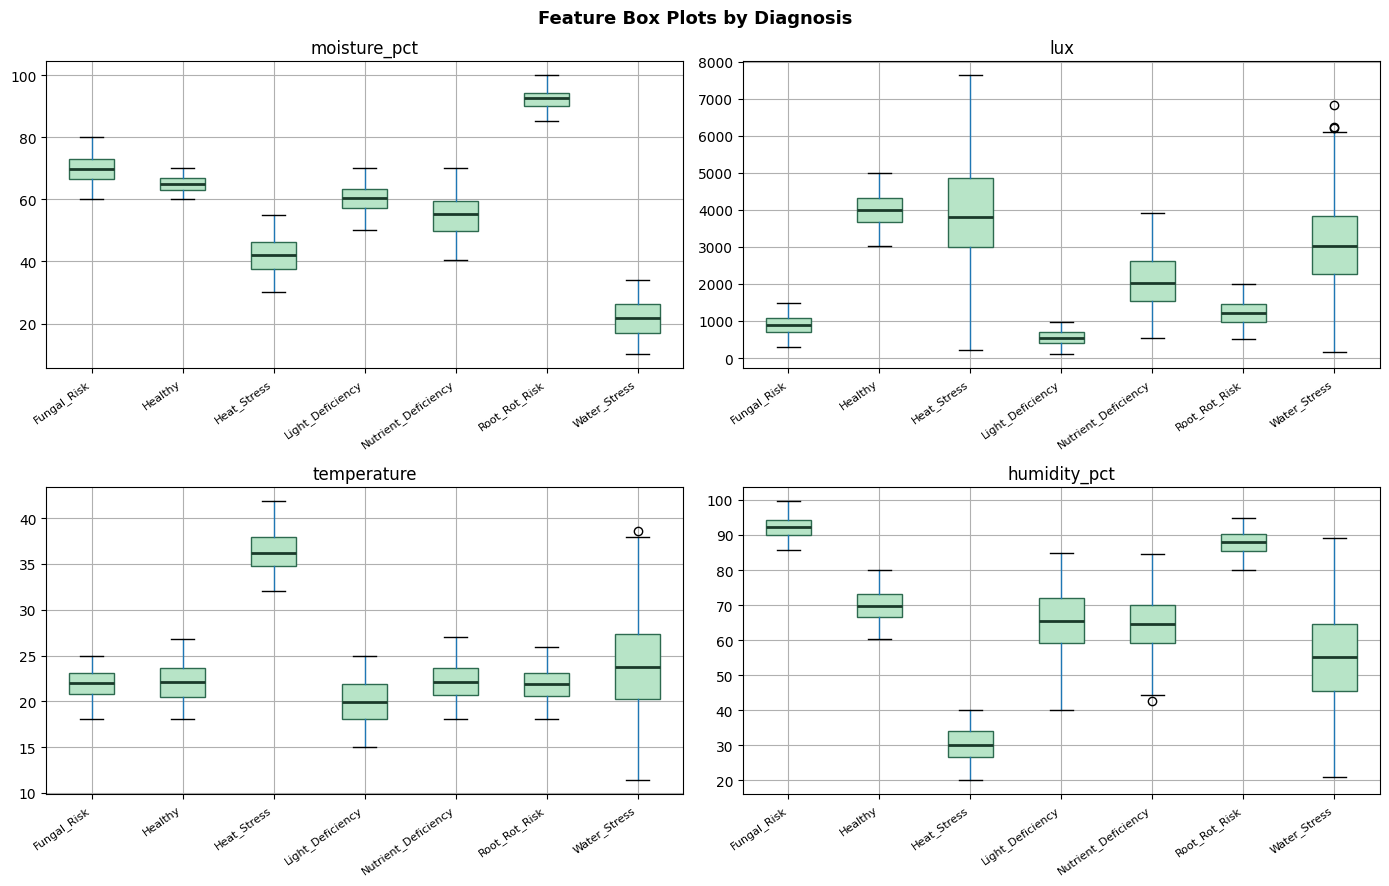

In [8]:
# Box plots — feature spread per class
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 2][idx % 2]
    df.boxplot(column=feature, by='diagnosis', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#b7e4c7', color='#2d6a4f'),
               medianprops=dict(color='#1a3a2a', linewidth=2))
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)

plt.suptitle('Feature Box Plots by Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Preprocessing



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# X: 4 sensor feature columns
X = df[feature_cols].values  # shape: (3800, 4)

# y: One-Hot Encode the diagnosis string column
# pd.get_dummies sorts alphabetically - consistent column order every run
y_ohe = pd.get_dummies(df['diagnosis']).astype(float)
CLASS_NAMES = list(y_ohe.columns)   # save the exact column order for later
y = y_ohe.values                    # shape: (3800, 7)

print('Feature matrix X shape :', X.shape)
print('OHE target y shape     :', y.shape)
print('Class order (OHE cols) :', CLASS_NAMES)

Feature matrix X shape : (3800, 4)
OHE target y shape     : (3800, 7)
Class order (OHE cols) : ['Fungal_Risk', 'Healthy', 'Heat_Stress', 'Light_Deficiency', 'Nutrient_Deficiency', 'Root_Rot_Risk', 'Water_Stress']


In [10]:
# Use argmax of OHE to get class labels for stratification
y_labels = np.argmax(y, axis=1)

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp, yl_train, yl_temp = train_test_split(
    X, y, y_labels, test_size=0.20, random_state=42, stratify=y_labels)

# Second split: 50% of temp - val (10%), 50%  test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=yl_temp)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Val set   : {X_val.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')

Train set : 3040 samples
Val set   : 380 samples
Test set  : 380 samples


In [11]:
# StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print('Scaler means :', scaler.mean_.round(3))
print('Scaler stds  :', scaler.scale_.round(3))

# Save scaler
joblib.dump(scaler, OUTPUT_DIR + 'scaler.pkl')
print(' Scaler saved to Drive.')


Scaler means : [  57.426 2372.903   23.951   66.196]
Scaler stds  : [  21.155 1561.421    5.629   20.181]
 Scaler saved to Drive.


---
## Build & Train the Keras MLP Model


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('GPU available     :', len(tf.config.list_physical_devices('GPU')) > 0)

# Model definition
tf.random.set_seed(42)

model = keras.Sequential([
    keras.Input(shape=(4,), name='sensor_input'),
    layers.Dense(16, activation='relu', name='hidden_1'),
    layers.Dropout(0.15, name='dropout_1'),
    layers.Dense(12, activation='relu', name='hidden_2'),
    layers.Dropout(0.10, name='dropout_2'),
    layers.Dense(len(CLASS_NAMES), activation='softmax', name='diagnosis_output'),
], name='AgriBloomModel')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

TensorFlow version: 2.19.0
GPU available     : False


Model: "AgriBloomModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ diagnosis_output (Dense)        │ (None, 7)              │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 375 (1.46 KB)

 Trainable params: 375 (1.46 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

CHECKPOINT_PATH = OUTPUT_DIR + 'best_model.keras'

callbacks = [
    # Stop training when val_loss stops improving for 15 epochs
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    # Reduce LR by 50% when val_loss plateaus for 7 epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1),
    # Save the best model checkpoint to Drive
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, verbose=0),
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('\n Training complete.')

Epoch 1/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3066 - loss: 1.7489 - val_accuracy: 0.7026 - val_loss: 1.4746 - learning_rate: 0.0010
Epoch 2/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6431 - loss: 1.2978 - val_accuracy: 0.7895 - val_loss: 1.0065 - learning_rate: 0.0010
Epoch 3/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 0.9253 - val_accuracy: 0.8632 - val_loss: 0.6466 - learning_rate: 0.0010
Epoch 4/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7977 - loss: 0.6718 - val_accuracy: 0.8711 - val_loss: 0.4574 - learning_rate: 0.0010
Epoch 5/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8115 - loss: 0.5542 - val_accuracy: 0.8974 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 6/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8352 - loss: 0.4631 - val_accuracy: 0.9132 - val_loss: 0.3035 - learning_rate: 0.0010
Epoch 7/200
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8510 - loss: 0.4196 - val_acc

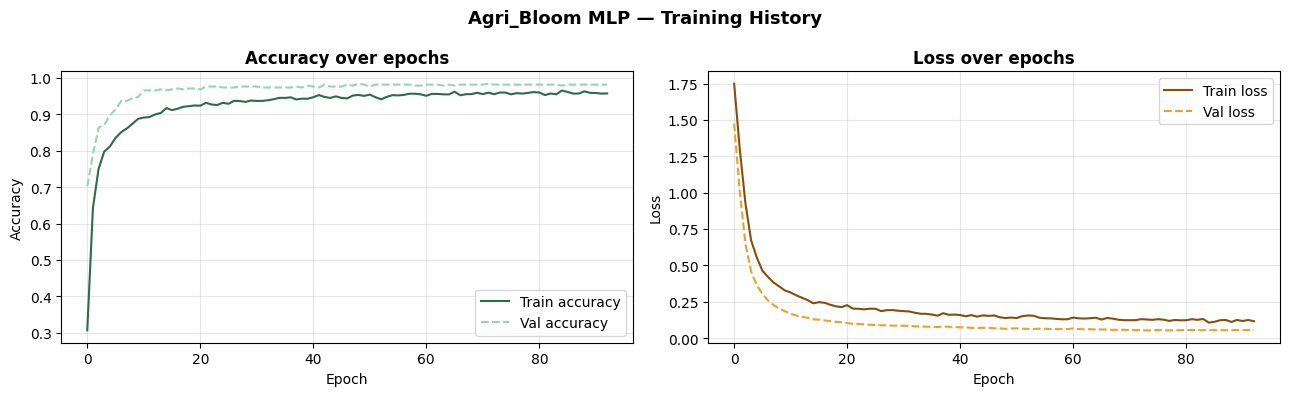

In [14]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],     label='Train accuracy',  color='#2D6A4F')
ax1.plot(history.history['val_accuracy'], label='Val accuracy',    color='#95D5B2', linestyle='--')
ax1.set_title('Accuracy over epochs', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train loss',  color='#854F0B')
ax2.plot(history.history['val_loss'], label='Val loss',    color='#EF9F27', linestyle='--')
ax2.set_title('Loss over epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Agri_Bloom MLP — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Evaluate the Model


In [15]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

# Predictions on test set
y_pred_proba = model.predict(X_test_s, verbose=0)
y_pred_idx   = np.argmax(y_pred_proba, axis=1)
y_true_idx   = np.argmax(y_test, axis=1)

acc       = accuracy_score(y_true_idx, y_pred_idx)
f1_macro  = f1_score(y_true_idx, y_pred_idx, average='macro')
f1_weight = f1_score(y_true_idx, y_pred_idx, average='weighted')

print('  Test Set Evaluation')
print(f'  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Macro F1-score    : {f1_macro:.4f}  (target ≥ 0.82)')
print(f'  Weighted F1-score : {f1_weight:.4f}')
if f1_macro >= 0.82:
    print('  NFR-04 PASSED — F1 ≥ 0.82')
else:
    print('  NFR-04 NOT MET — consider tuning the model')

print()
print('Per-class Classification Report:')
print(classification_report(y_true_idx, y_pred_idx, target_names=CLASS_NAMES))

  Test Set Evaluation
  Accuracy          : 0.9895  (98.95%)
  Macro F1-score    : 0.9886  (target ≥ 0.82)
  Weighted F1-score : 0.9895
  NFR-04 PASSED — F1 ≥ 0.82

Per-class Classification Report:
                     precision    recall  f1-score   support

        Fungal_Risk       1.00      1.00      1.00        50
            Healthy       1.00      1.00      1.00        70
        Heat_Stress       1.00      1.00      1.00        50
   Light_Deficiency       0.93      1.00      0.96        50
Nutrient_Deficiency       1.00      0.92      0.96        50
      Root_Rot_Risk       1.00      1.00      1.00        50
       Water_Stress       1.00      1.00      1.00        60

           accuracy                           0.99       380
          macro avg       0.99      0.99      0.99       380
       weighted avg       0.99      0.99      0.99       380



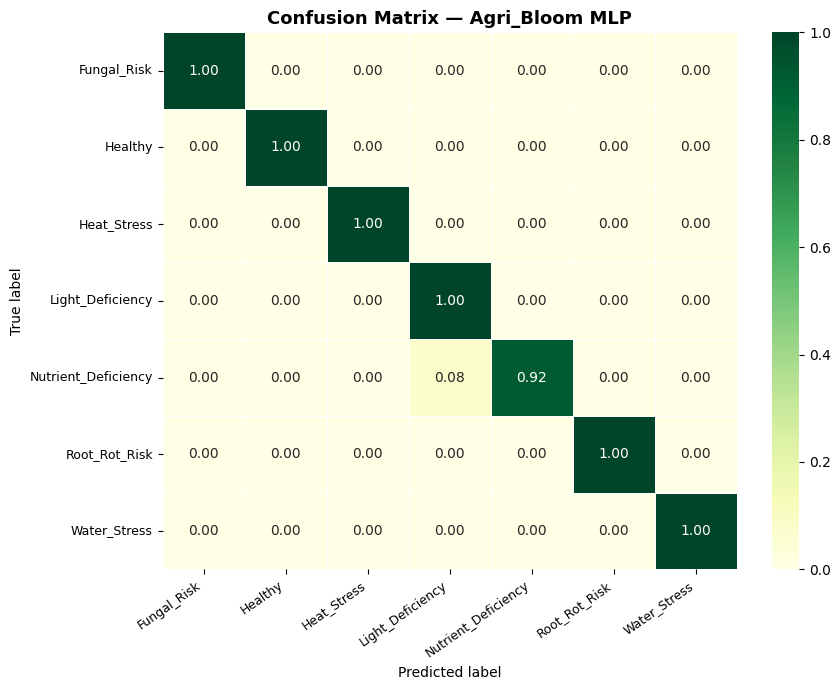

Confusion matrix saved to Drive.


In [18]:
# Confusion matrix heatmap
cm = confusion_matrix(y_true_idx, y_pred_idx)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Confusion Matrix — Agri_Bloom MLP', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()

# Save confusion matrix figure to Drive
plt.savefig(OUTPUT_DIR + 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved to Drive.')

---
## Convert to TensorFlow Lite (int8 quantised)

We use **full integer quantisation** with a representative dataset.  
This compresses the model from float32 (5 KB) to int8 (3 KB) and is required for TFLite Micro on ESP32.

The final `.tflite` file must be **< 15 KB** to fit in ESP32 flash alongside firmware.

In [19]:
#  Representative dataset generator (used for int8 calibration)
def representative_dataset():
    """Feeds 200 training samples to calibrate the quantisation ranges."""
    for i in range(min(200, len(X_train_s))):
        sample = X_train_s[i].astype(np.float32).reshape(1, 4)
        yield [sample]

#  TFLite Converter setup
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Full int8 post-training quantisation
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

# Convert
tflite_model = converter.convert()

# Show model size
size_bytes = len(tflite_model)
print(f' TFLite model size : {size_bytes} bytes  ({size_bytes/1024:.2f} KB)')
if size_bytes < 15 * 1024:
    print(' Size OK — fits in ESP32 flash.')
else:
    print('  Model is large — consider reducing hidden layer sizes.')

Saved artifact at '/tmp/tmpbeajzfsx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134521453714640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134521453715984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134521453717328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134521453715600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134521453715408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134521453717520: TensorSpec(shape=(), dtype=tf.resource, name=None)
 TFLite model size : 3840 bytes  (3.75 KB)
 Size OK — fits in ESP32 flash.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [20]:
# Save .tflite to Google Drive
TFLITE_PATH = OUTPUT_DIR + 'agri_bloom_model.tflite'

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f' Saved: {TFLITE_PATH}')
print(f' File size: {os.path.getsize(TFLITE_PATH)} bytes')

 Saved: /content/drive/MyDrive/Agri-Bloom/outputs/agri_bloom_model.tflite
 File size: 3840 bytes
